- **Purpose**: Handle *Beam Search* and *Init-Inject*.
- **Content**: These require different generation loops. Compare BLEU-4 against the greedy pre-inject baseline from notebook `04`.

In [3]:
import sys
import os
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
os.environ["XLA_FLAGS"] = "--xla_gpu_cuda_data_dir=/usr/lib/cuda --xla_gpu_enable_triton_gemm=false"
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from collections import defaultdict

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

PROJECT_ROOT = Path("../../")
sys.path.append(str(PROJECT_ROOT))

from src.utility.text_utils import TextTokenizer
from src.nn import no_grad
from src.nn.layers.dense import Dense
from src.nn.layers.embedding import Embedding
from src.nn.layers.recurrent import SimpleRNNCell, LSTMCell

DATA_DIR        = PROJECT_ROOT / "data" / "2_rnn_image_captioning"
FEATURES_DIR    = DATA_DIR / "features"
IMAGES_DIR      = DATA_DIR / "images"
WEIGHTS_DIR     = PROJECT_ROOT / "models" / "rnn_lstm"
VOCAB_PATH      = DATA_DIR / "vocab.json"

SEED            = 42
np.random.seed(SEED)
EMBED_DIM       = 128
EPOCHS          = 10
BATCH_SIZE      = 32
CNN_FEATURE_DIM = 2048
TRAIN_SPLIT     = 6000
VAL_SPLIT       = 1000

# ── Update these after running notebook 04 ──────────────────────────────────
BEST_RNN  = {"n_layers": 1, "hidden_size": 256}
BEST_LSTM = {"n_layers": 1, "hidden_size": 256}
# ────────────────────────────────────────────────────────────────────────────

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU ready: {[g.name for g in gpus]}")
else:
    print("No GPU — running on CPU.")

I0000 00:00:1778848716.626345   20774 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778848717.379644   20774 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778848719.597803   20774 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GPU ready: ['/physical_device:GPU:0']


In [5]:
tokenizer = TextTokenizer()
tokenizer.load_vocab(str(VOCAB_PATH))

with open(DATA_DIR / "config.json") as f:
    config = json.load(f)
VOCAB_SIZE = config['vocab_size']
MAX_LEN    = config['max_length']

START_ID = tokenizer.token_to_id['<start>']
END_ID   = tokenizer.token_to_id['<end>']
PAD_ID   = tokenizer.token_to_id['<pad>']

def load_captions(filepath):
    captions = defaultdict(list)
    with open(filepath, "r") as f:
        next(f)
        for line in f:
            line = line.strip()
            if not line:
                continue
            image_id, caption = line.split(",", 1)
            image_id = image_id.rsplit(".", 1)[0]
            captions[image_id].append(caption.strip())
    return captions

all_captions = load_captions(DATA_DIR / "captions.txt")

image_ids    = np.load(DATA_DIR / "image_ids.npy", allow_pickle=True)
image_ids_clean = np.array([img_id.rsplit(".", 1)[0] if "." in img_id else img_id for img_id in image_ids])
unique_ids   = list(dict.fromkeys(image_ids_clean))
test_ids     = set(unique_ids[TRAIN_SPLIT + VAL_SPLIT : TRAIN_SPLIT + VAL_SPLIT + 1000])

padded_sequences = np.load(DATA_DIR / "processed_captions.npy")

feature_cache = {}
for npy_file in FEATURES_DIR.glob("*.npy"):
    feature_cache[npy_file.stem] = np.load(npy_file)

train_ids = set(unique_ids[:TRAIN_SPLIT])
val_ids   = set(unique_ids[TRAIN_SPLIT:TRAIN_SPLIT + VAL_SPLIT])

print(f"Vocab size  : {VOCAB_SIZE}")
print(f"Max length  : {MAX_LEN}")
print(f"Test images : {len(test_ids)}")
print(f"Features    : {len(feature_cache)}")

Vocab size  : 8832
Max length  : 38
Test images : 1000
Features    : 8091


In [6]:
class MultiLayerRNN:
    def __init__(self, cells):
        self.cells = cells

    def forward(self, x_t, h_states):
        new_h = []
        inp = x_t
        for i, cell in enumerate(self.cells):
            h_new = cell.forward(inp, h_states[i])
            new_h.append(h_new)
            inp = h_new
        return inp, new_h


class MultiLayerLSTM:
    def __init__(self, cells):
        self.cells = cells

    def forward(self, x_t, h_states, c_states):
        new_h, new_c = [], []
        inp = x_t
        for i, cell in enumerate(self.cells):
            h_new, c_new = cell.forward(inp, h_states[i], c_states[i])
            new_h.append(h_new)
            new_c.append(c_new)
            inp = h_new
        return inp, new_h, new_c


def load_feature(image_id):
    return np.load(str(FEATURES_DIR / f"{image_id}.npy"))


def compute_bleu4(hypotheses, references_list):
    smoothie = SmoothingFunction().method4
    refs = [[r.split() for r in ref_strs] for ref_strs in references_list]
    hyps = [h.split() for h in hypotheses]
    return corpus_bleu(refs, hyps, smoothing_function=smoothie)


def compute_meteor(hypotheses, references_list):
    scores = [meteor_score([r.split() for r in refs], hyp.split())
              for hyp, refs in zip(hypotheses, references_list)]
    return float(np.mean(scores))


def evaluate_model(generate_fn, test_ids, all_captions, max_len=30, batch_size=32):
    hypotheses, references_list = [], []
    test_ids_list = list(test_ids)
    start_time = time.time()
    for i in range(0, len(test_ids_list), batch_size):
        batch_ids = test_ids_list[i:i + batch_size]
        features  = np.array([load_feature(img_id) for img_id in batch_ids])
        batch_caps = generate_fn(features, max_len=max_len)
        for img_id, token_ids in zip(batch_ids, batch_caps):
            hypotheses.append(tokenizer.decode(token_ids))
            references_list.append(all_captions[img_id])
    elapsed = time.time() - start_time
    bleu4   = compute_bleu4(hypotheses, references_list)
    meteor  = compute_meteor(hypotheses, references_list)
    return bleu4, meteor, elapsed, hypotheses, references_list


def build_dataset(sequences, img_ids):
    img_features, cap_inputs, cap_targets = [], [], []
    for seq, img_id in zip(sequences, img_ids):
        img_id_clean = img_id.rsplit(".", 1)[0] if "." in img_id else img_id
        if img_id_clean not in feature_cache:
            continue
        img_features.append(feature_cache[img_id_clean])
        cap_inputs.append(seq[:-1])
        cap_targets.append(seq[1:])
    return (np.array(img_features, dtype=np.float32),
            np.array(cap_inputs,   dtype=np.int32),
            np.array(cap_targets,  dtype=np.int32))

---
## BONUS 1: Init-Inject Architecture

In **Init-inject**, the CNN feature vector initialises the hidden state h₀ instead of being prepended as x₋₁.

- `h₀ = Dense(tanh)(CNN_feature)` → first-layer initial hidden state  
- `c₀ = zeros` (LSTM only)  
- Input sequence starts directly from `<start>` — no image timestep

This is trained as a separate Keras model and compared against the pre-inject greedy baseline.

In [11]:
def build_init_inject_decoder(cell_type, num_layers, hidden_size, vocab_size, embed_dim, max_len, cnn_dim):
    assert cell_type in ('rnn', 'lstm')

    img_input = keras.Input(shape=(cnn_dim,), name='image_feature')
    cap_input = keras.Input(shape=(max_len - 1,), dtype='int32', name='caption_input')

    h0 = layers.Dense(hidden_size, activation='tanh', name='h0_projection')(img_input)

    cap_emb = layers.Embedding(vocab_size, embed_dim, name='embedding')(cap_input)

    x = cap_emb
    for i in range(num_layers):
        name = f'{cell_type}_{i+1}'
        if cell_type == 'rnn':
            init_state = [h0] if i == 0 else None
            x = layers.SimpleRNN(hidden_size, return_sequences=True, name=name)(
                x, initial_state=init_state)
        else:
            if i == 0:
                c0 = layers.Dense(hidden_size, use_bias=False, kernel_initializer='zeros', trainable=False, name='c0_zeros')(h0)
                x = layers.LSTM(hidden_size, return_sequences=True, name=name)(
                    x, initial_state=[h0, c0])
            else:
                x = layers.LSTM(hidden_size, return_sequences=True, name=name)(x)

    output = layers.Dense(vocab_size, activation='softmax', name='output')(x)

    model = keras.Model(inputs=[img_input, cap_input], outputs=output)
    model.compile(
        optimizer=keras.optimizers.Adam(),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


train_mask = np.array([img_id in train_ids for img_id in image_ids_clean])
val_mask   = np.array([img_id in val_ids   for img_id in image_ids_clean])

train_feats, train_cap_in, train_cap_out = build_dataset(padded_sequences[train_mask], image_ids[train_mask])
val_feats,   val_cap_in,   val_cap_out   = build_dataset(padded_sequences[val_mask],   image_ids[val_mask])

print(f"Train samples : {len(train_feats)}")
print(f"Val   samples : {len(val_feats)}")

INIT_INJECT_VARIANTS = [
    {"arch": "rnn",  "n_layers": BEST_RNN["n_layers"],  "hidden_size": BEST_RNN["hidden_size"]},
    {"arch": "lstm", "n_layers": BEST_LSTM["n_layers"], "hidden_size": BEST_LSTM["hidden_size"]},
]

Train samples : 30000
Val   samples : 5000


In [12]:
init_inject_histories = {}

for v in INIT_INJECT_VARIANTS:
    arch, n_layers, hsize = v["arch"], v["n_layers"], v["hidden_size"]
    tag          = f"{arch}_init_inject_L{n_layers}_H{hsize}"
    weights_path = WEIGHTS_DIR / f"{tag}.keras"

    print(f"\n{'-'*60}")
    print(f"Training Init-Inject {tag}")
    print(f"{'-'*60}")

    model = build_init_inject_decoder(arch, n_layers, hsize, VOCAB_SIZE, EMBED_DIM, MAX_LEN, CNN_FEATURE_DIM)

    callbacks = [
        ModelCheckpoint(str(weights_path), monitor='val_loss', save_best_only=True, verbose=0),
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
    ]

    history = model.fit(
        x=[train_feats, train_cap_in],
        y=train_cap_out,
        validation_data=([val_feats, val_cap_in], val_cap_out),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )

    init_inject_histories[tag] = history.history
    print(f"Saved → {weights_path}")

print("\nInit-inject training done.")


------------------------------------------------------------
Training Init-Inject rnn_init_inject_L1_H256
------------------------------------------------------------
Epoch 1/10


I0000 00:00:1778848877.910328   21683 service.cc:153] XLA service 0x7d04c40044c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778848877.910378   21683 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.10.2)
I0000 00:00:1778848877.977750   21683 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
W0000 00:00:1778848878.073534   21683 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1778848878.192353   21683 cuda_dnn.cc:461] Loaded cuDNN version 91002
I0000 00:00:1778848878.217920   21683 dot_merger.cc:481] Merging Dots in computation: functional_1_rnn_1_1_while_body_2359_grad_2562_const_0__.24.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:177884887

  1/938 ━━━━━━━━━━━━━━━━━━━━ 55:57 4s/step - accuracy: 0.0000e+00 - loss: 9.0850

I0000 00:00:1778848880.342030   21683 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


937/938 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7335 - loss: 2.0780

W0000 00:00:1778848906.719130   21687 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1778848906.797137   21687 dot_merger.cc:481] Merging Dots in computation: functional_1_rnn_1_1_while_body_2359_grad_2562_const_0__.24.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1778848906.797265   21687 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3120__.28


938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7335 - loss: 2.0774

W0000 00:00:1778848908.751171   21683 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1778848911.078631   21687 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


938/938 ━━━━━━━━━━━━━━━━━━━━ 35s 34ms/step - accuracy: 0.7630 - loss: 1.4923 - val_accuracy: 0.7808 - val_loss: 1.2227
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 28s 30ms/step - accuracy: 0.7915 - loss: 1.1082 - val_accuracy: 0.7914 - val_loss: 1.1274
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 42s 33ms/step - accuracy: 0.7994 - loss: 1.0087 - val_accuracy: 0.7950 - val_loss: 1.0857
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 31ms/step - accuracy: 0.8049 - loss: 0.9435 - val_accuracy: 0.7973 - val_loss: 1.0697
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 26s 28ms/step - accuracy: 0.8095 - loss: 0.8942 - val_accuracy: 0.7998 - val_loss: 1.0611
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 28s 29ms/step - accuracy: 0.8138 - loss: 0.8548 - val_accuracy: 0.8000 - val_loss: 1.0609
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.8171 - loss: 0.8208 - val_accuracy: 0.7991 - val_loss: 1.0654
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 27s 29ms/step - accuracy: 0.8205 - loss: 0.7913 - val_accurac

In [13]:
def load_rnn_init_inject(keras_model_path, n_layers):
    with tf.device('/CPU:0'):
        keras_model = tf.keras.models.load_model(keras_model_path, safe_mode=False)

    h0_W, h0_b = keras_model.get_layer('h0_projection').get_weights()
    h0_dense = Dense.from_weights(h0_W, h0_b, activation='tanh')

    emb_W = keras_model.get_layer('embedding').get_weights()[0]
    embedding = Embedding.from_weights(emb_W)

    cells = []
    for i in range(n_layers):
        W_ih, W_hh, b = keras_model.get_layer(f'rnn_{i+1}').get_weights()
        cells.append(SimpleRNNCell.from_weights(W_ih, W_hh, b))

    out_W, out_b = keras_model.get_layer('output').get_weights()
    output_dense = Dense.from_weights(out_W, out_b, activation='softmax')

    return embedding, h0_dense, MultiLayerRNN(cells), output_dense


def load_lstm_init_inject(keras_model_path, n_layers):
    with tf.device('/CPU:0'):
        keras_model = tf.keras.models.load_model(keras_model_path, safe_mode=False)

    h0_W, h0_b = keras_model.get_layer('h0_projection').get_weights()
    h0_dense = Dense.from_weights(h0_W, h0_b, activation='tanh')

    emb_W = keras_model.get_layer('embedding').get_weights()[0]
    embedding = Embedding.from_weights(emb_W)

    cells = []
    for i in range(n_layers):
        W_ih, W_hh, b = keras_model.get_layer(f'lstm_{i+1}').get_weights()
        cells.append(LSTMCell.from_weights(W_ih, W_hh, b))

    out_W, out_b = keras_model.get_layer('output').get_weights()
    output_dense = Dense.from_weights(out_W, out_b, activation='softmax')

    return embedding, h0_dense, MultiLayerLSTM(cells), output_dense


def generate_init_inject_rnn(image_features, embedding, h0_dense, rnn, output_dense, max_len=30):
    if image_features.ndim == 1:
        image_features = image_features.reshape(1, -1)
    B           = image_features.shape[0]
    hidden_size = rnn.cells[0].hidden_size
    n_layers    = len(rnn.cells)

    with no_grad():
        h_init   = h0_dense.forward(image_features)
        h_states = [h_init.data] + [np.zeros((B, hidden_size)) for _ in range(n_layers - 1)]

        tokens   = np.full(B, START_ID, dtype=np.int32)
        captions = [[] for _ in range(B)]
        done     = np.zeros(B, dtype=bool)

        for _ in range(max_len):
            x = embedding.forward(tokens)
            h_out, h_states_t = rnn.forward(x, h_states)
            h_states = [h.data for h in h_states_t]
            probs       = output_dense.forward(h_out)
            next_tokens = np.argmax(probs.data, axis=-1).flatten()

            for i in range(B):
                if not done[i]:
                    if next_tokens[i] == END_ID:
                        done[i] = True
                    else:
                        captions[i].append(int(next_tokens[i]))

            tokens = next_tokens
            if done.all():
                break

    return captions


def generate_init_inject_lstm(image_features, embedding, h0_dense, lstm, output_dense, max_len=30):
    if image_features.ndim == 1:
        image_features = image_features.reshape(1, -1)
    B           = image_features.shape[0]
    hidden_size = lstm.cells[0].hidden_size
    n_layers    = len(lstm.cells)

    with no_grad():
        h_init   = h0_dense.forward(image_features)
        h_states = [h_init.data] + [np.zeros((B, hidden_size)) for _ in range(n_layers - 1)]
        c_states = [np.zeros((B, hidden_size)) for _ in range(n_layers)]

        tokens   = np.full(B, START_ID, dtype=np.int32)
        captions = [[] for _ in range(B)]
        done     = np.zeros(B, dtype=bool)

        for _ in range(max_len):
            x = embedding.forward(tokens)
            h_out, h_states_t, c_states_t = lstm.forward(x, h_states, c_states)
            h_states = [h.data for h in h_states_t]
            c_states = [c.data for c in c_states_t]
            probs       = output_dense.forward(h_out)
            next_tokens = np.argmax(probs.data, axis=-1).flatten()

            for i in range(B):
                if not done[i]:
                    if next_tokens[i] == END_ID:
                        done[i] = True
                    else:
                        captions[i].append(int(next_tokens[i]))

            tokens = next_tokens
            if done.all():
                break

    return captions

In [14]:
init_inject_results = []

for v in INIT_INJECT_VARIANTS:
    arch, n_layers, hsize = v["arch"], v["n_layers"], v["hidden_size"]
    tag        = f"{arch}_init_inject_L{n_layers}_H{hsize}"
    model_path = WEIGHTS_DIR / f"{tag}.keras"

    if not model_path.exists():
        print(f"[SKIP] {model_path.name} not found")
        continue

    print(f"Evaluating Init-Inject {arch.upper()} L={n_layers} H={hsize} ...", end=" ")

    if arch == "rnn":
        emb, h0d, dec, out = load_rnn_init_inject(str(model_path), n_layers)
        gen_fn = lambda feat, max_len=MAX_LEN, _e=emb, _h=h0d, _d=dec, _o=out:             generate_init_inject_rnn(feat, _e, _h, _d, _o, max_len)
    else:
        emb, h0d, dec, out = load_lstm_init_inject(str(model_path), n_layers)
        gen_fn = lambda feat, max_len=MAX_LEN, _e=emb, _h=h0d, _d=dec, _o=out:             generate_init_inject_lstm(feat, _e, _h, _d, _o, max_len)

    bleu4, meteor, elapsed, hyps, refs = evaluate_model(gen_fn, test_ids, all_captions)
    print(f"BLEU-4={bleu4:.4f} | METEOR={meteor:.4f} | Time={elapsed:.1f}s")

    init_inject_results.append({
        "method": "Init-Inject", "arch": arch.upper(),
        "n_layers": n_layers, "hidden_size": hsize,
        "bleu4": bleu4, "meteor": meteor, "time": elapsed,
    })

print("\nInit-Inject vs Pre-Inject Comparison")
print("-" * 70)
print(f"{'Method':<20} {'Arch':<6} {'L':<4} {'H':<6} {'BLEU-4':<10} {'METEOR':<10} {'Time':>6}")
print("-" * 70)

pre_inject_csv = WEIGHTS_DIR / "nb04_results.csv"
if pre_inject_csv.exists():
    df_pre = pd.read_csv(pre_inject_csv)
    for _, row in df_pre.iterrows():
        if row["n_layers"] == BEST_RNN["n_layers"] and row["hidden_size"] == BEST_RNN["hidden_size"] and row["arch"] == "rnn":
            print(f"{'Pre-Inject':<20} {'RNN':<6} {row['n_layers']:<4} {row['hidden_size']:<6} {row['bleu4']:<10.4f} {row['meteor']:<10.4f} {row['time']:>6.1f}s")
        if row["n_layers"] == BEST_LSTM["n_layers"] and row["hidden_size"] == BEST_LSTM["hidden_size"] and row["arch"] == "lstm":
            print(f"{'Pre-Inject':<20} {'LSTM':<6} {row['n_layers']:<4} {row['hidden_size']:<6} {row['bleu4']:<10.4f} {row['meteor']:<10.4f} {row['time']:>6.1f}s")
else:
    print("(Pre-inject results not found — save nb04_results.csv from notebook 04)")

for r in init_inject_results:
    print(f"{'Init-Inject':<20} {r['arch']:<6} {r['n_layers']:<4} {r['hidden_size']:<6} {r['bleu4']:<10.4f} {r['meteor']:<10.4f} {r['time']:>6.1f}s")

Evaluating Init-Inject RNN L=1 H=256 ... BLEU-4=0.1092 | METEOR=0.3072 | Time=6.3s
Evaluating Init-Inject LSTM L=1 H=256 ... BLEU-4=0.0943 | METEOR=0.2957 | Time=10.4s

Init-Inject vs Pre-Inject Comparison
----------------------------------------------------------------------
Method               Arch   L    H      BLEU-4     METEOR       Time
----------------------------------------------------------------------
(Pre-inject results not found — save nb04_results.csv from notebook 04)
Init-Inject          RNN    1    256    0.1092     0.3072        6.3s
Init-Inject          LSTM   1    256    0.0943     0.2957       10.4s


---
## BONUS 2: Beam Search Decoder

Beam search maintains **k** candidate sequences at each step instead of committing greedily to the single best token.  
At each timestep, all beams are expanded over the full vocabulary and the top-k cumulative log-probability sequences are kept.

Tested with `k = 3` and `k = 5` on the best pre-inject RNN and LSTM models from notebook 04.

In [7]:
from src.nn.layers.dense import Dense
from src.nn.layers.embedding import Embedding
from src.nn.layers.recurrent import SimpleRNNCell, LSTMCell


def load_rnn_decoder(keras_model_path, n_layers):
    with tf.device('/CPU:0'):
        keras_model = tf.keras.models.load_model(keras_model_path, safe_mode=False)
    weights = keras_model.get_weights()
    idx = 0

    proj_W = weights[idx]; idx += 1
    proj_b = weights[idx]; idx += 1
    proj_dense = Dense.from_weights(proj_W, proj_b, activation='linear')

    emb_W = weights[idx]; idx += 1
    embedding = Embedding.from_weights(emb_W)

    cells = []
    for _ in range(n_layers):
        W_ih = weights[idx]; idx += 1
        W_hh = weights[idx]; idx += 1
        b    = weights[idx]; idx += 1
        cells.append(SimpleRNNCell.from_weights(W_ih, W_hh, b))

    out_W = weights[idx]; idx += 1
    out_b = weights[idx]; idx += 1
    output_dense = Dense.from_weights(out_W, out_b, activation='softmax')

    return embedding, proj_dense, MultiLayerRNN(cells), output_dense


def load_lstm_decoder(keras_model_path, n_layers):
    with tf.device('/CPU:0'):
        keras_model = tf.keras.models.load_model(keras_model_path, safe_mode=False)
    weights = keras_model.get_weights()
    idx = 0

    proj_W = weights[idx]; idx += 1
    proj_b = weights[idx]; idx += 1
    proj_dense = Dense.from_weights(proj_W, proj_b, activation='linear')

    emb_W = weights[idx]; idx += 1
    embedding = Embedding.from_weights(emb_W)

    cells = []
    for _ in range(n_layers):
        W_ih = weights[idx]; idx += 1
        W_hh = weights[idx]; idx += 1
        b    = weights[idx]; idx += 1
        cells.append(LSTMCell.from_weights(W_ih, W_hh, b))

    out_W = weights[idx]; idx += 1
    out_b = weights[idx]; idx += 1
    output_dense = Dense.from_weights(out_W, out_b, activation='softmax')

    return embedding, proj_dense, MultiLayerLSTM(cells), output_dense


rnn_arch_counters  = {"rnn": 0, "lstm": 0}
VARIATIONS = [
    {'layers': 1, 'hidden': 128}, {'layers': 1, 'hidden': 256},
    {'layers': 2, 'hidden': 128}, {'layers': 2, 'hidden': 256},
    {'layers': 3, 'hidden': 128}, {'layers': 3, 'hidden': 256},
]

def find_v_idx(arch, n_layers, hidden):
    counter = 0
    for v in VARIATIONS:
        if v['layers'] == n_layers and v['hidden'] == hidden:
            return counter + 1
        counter += 1
    return 1

rnn_n,  rnn_h  = BEST_RNN["n_layers"],  BEST_RNN["hidden_size"]
lstm_n, lstm_h = BEST_LSTM["n_layers"], BEST_LSTM["hidden_size"]

rnn_v_idx  = find_v_idx("rnn",  rnn_n,  rnn_h)
lstm_v_idx = find_v_idx("lstm", lstm_n, lstm_h)

rnn_path  = WEIGHTS_DIR / f"rnn_v{rnn_v_idx}_L{rnn_n}_H{rnn_h}.keras"
lstm_path = WEIGHTS_DIR / f"lstm_v{lstm_v_idx}_L{lstm_n}_H{lstm_h}.keras"

print(f"Loading RNN  : {rnn_path.name}")
rnn_emb,  rnn_proj,  rnn_dec,  rnn_out  = load_rnn_decoder(str(rnn_path),  rnn_n)

print(f"Loading LSTM : {lstm_path.name}")
lstm_emb, lstm_proj, lstm_dec, lstm_out = load_lstm_decoder(str(lstm_path), lstm_n)

print("Models loaded.")

Loading RNN  : rnn_v2_L1_H256.keras
Loading LSTM : lstm_v2_L1_H256.keras
Models loaded.


In [16]:
def generate_beam_rnn(image_feature, embedding, proj_dense, rnn, output_dense, beam_size=3, max_len=30):
    hidden_size = rnn.cells[0].hidden_size
    n_layers    = len(rnn.cells)
    feat        = image_feature.reshape(1, -1)

    with no_grad():
        h_states = [np.zeros((1, hidden_size)) for _ in range(n_layers)]
        x = proj_dense.forward(feat)
        _, h_out_states = rnn.forward(x, h_states)
        h_np = [h.data.copy() for h in h_out_states]

        x = embedding.forward(np.array([START_ID]))
        h_out, h_out_states = rnn.forward(x, h_np)
        probs = output_dense.forward(h_out).data[0]
        h_np  = [h.data.copy() for h in h_out_states]

        log_p  = np.log(probs + 1e-10)
        top_k  = np.argsort(log_p)[-beam_size:][::-1]
        beams  = [{"score": log_p[t], "tokens": [int(t)], "h": [h.copy() for h in h_np]}
                  for t in top_k]
        completed = []

        for _ in range(max_len - 1):
            all_cands = []
            for beam in beams:
                if beam["tokens"][-1] == END_ID:
                    completed.append(beam)
                    continue
                last_tok = np.array([beam["tokens"][-1]])
                x = embedding.forward(last_tok)
                h_out, h_out_states = rnn.forward(x, beam["h"])
                probs = output_dense.forward(h_out).data[0]
                h_np  = [h.data.copy() for h in h_out_states]
                log_p = np.log(probs + 1e-10)
                for tok in np.argsort(log_p)[-beam_size:][::-1]:
                    all_cands.append({
                        "score":  beam["score"] + log_p[tok],
                        "tokens": beam["tokens"] + [int(tok)],
                        "h":      [h.copy() for h in h_np]
                    })

            if not all_cands:
                break

            all_cands.sort(key=lambda b: b["score"], reverse=True)
            beams = []
            for cand in all_cands:
                if cand["tokens"][-1] == END_ID:
                    completed.append(cand)
                else:
                    beams.append(cand)
                if len(beams) >= beam_size:
                    break

            if len(completed) >= beam_size:
                break

        completed.extend(beams)
        if not completed:
            return []
        best = max(completed, key=lambda b: b["score"])
        return [t for t in best["tokens"] if t != END_ID]


def generate_beam_lstm(image_feature, embedding, proj_dense, lstm, output_dense, beam_size=3, max_len=30):
    hidden_size = lstm.cells[0].hidden_size
    n_layers    = len(lstm.cells)
    feat        = image_feature.reshape(1, -1)

    with no_grad():
        h_states = [np.zeros((1, hidden_size)) for _ in range(n_layers)]
        c_states = [np.zeros((1, hidden_size)) for _ in range(n_layers)]
        x = proj_dense.forward(feat)
        _, h_out_states, c_out_states = lstm.forward(x, h_states, c_states)
        h_np = [h.data.copy() for h in h_out_states]
        c_np = [c.data.copy() for c in c_out_states]

        x = embedding.forward(np.array([START_ID]))
        h_out, h_out_states, c_out_states = lstm.forward(x, h_np, c_np)
        probs = output_dense.forward(h_out).data[0]
        h_np  = [h.data.copy() for h in h_out_states]
        c_np  = [c.data.copy() for c in c_out_states]

        log_p  = np.log(probs + 1e-10)
        top_k  = np.argsort(log_p)[-beam_size:][::-1]
        beams  = [{"score": log_p[t], "tokens": [int(t)],
                   "h": [h.copy() for h in h_np], "c": [c.copy() for c in c_np]}
                  for t in top_k]
        completed = []

        for _ in range(max_len - 1):
            all_cands = []
            for beam in beams:
                if beam["tokens"][-1] == END_ID:
                    completed.append(beam)
                    continue
                last_tok = np.array([beam["tokens"][-1]])
                x = embedding.forward(last_tok)
                h_out, h_out_states, c_out_states = lstm.forward(x, beam["h"], beam["c"])
                probs = output_dense.forward(h_out).data[0]
                h_np  = [h.data.copy() for h in h_out_states]
                c_np  = [c.data.copy() for c in c_out_states]
                log_p = np.log(probs + 1e-10)
                for tok in np.argsort(log_p)[-beam_size:][::-1]:
                    all_cands.append({
                        "score":  beam["score"] + log_p[tok],
                        "tokens": beam["tokens"] + [int(tok)],
                        "h":      [h.copy() for h in h_np],
                        "c":      [c.copy() for c in c_np]
                    })

            if not all_cands:
                break

            all_cands.sort(key=lambda b: b["score"], reverse=True)
            beams = []
            for cand in all_cands:
                if cand["tokens"][-1] == END_ID:
                    completed.append(cand)
                else:
                    beams.append(cand)
                if len(beams) >= beam_size:
                    break

            if len(completed) >= beam_size:
                break

        completed.extend(beams)
        if not completed:
            return []
        best = max(completed, key=lambda b: b["score"])
        return [t for t in best["tokens"] if t != END_ID]


def evaluate_beam(generate_beam_fn, test_ids, all_captions, beam_size, max_len=30):
    hypotheses, references_list = [], []
    start_time = time.time()
    for image_id in list(test_ids):
        feature   = load_feature(image_id)
        token_ids = generate_beam_fn(feature)
        hypotheses.append(tokenizer.decode(token_ids))
        references_list.append(all_captions[image_id])
    elapsed = time.time() - start_time
    bleu4   = compute_bleu4(hypotheses, references_list)
    meteor  = compute_meteor(hypotheses, references_list)
    return bleu4, meteor, elapsed, hypotheses, references_list

In [17]:
def generate_greedy_rnn(image_features, embedding, proj_dense, rnn, output_dense, max_len=30):
    if image_features.ndim == 1:
        image_features = image_features.reshape(1, -1)
    B           = image_features.shape[0]
    hidden_size = rnn.cells[0].hidden_size
    n_layers    = len(rnn.cells)

    with no_grad():
        h_states = [np.zeros((B, hidden_size)) for _ in range(n_layers)]
        x = proj_dense.forward(image_features)
        _, h_states = rnn.forward(x, h_states)

        tokens   = np.full(B, START_ID, dtype=np.int32)
        captions = [[] for _ in range(B)]
        done     = np.zeros(B, dtype=bool)

        for _ in range(max_len):
            x = embedding.forward(tokens)
            h_out, h_states = rnn.forward(x, h_states)
            probs       = output_dense.forward(h_out)
            next_tokens = np.argmax(probs.data, axis=-1).flatten()
            for i in range(B):
                if not done[i]:
                    if next_tokens[i] == END_ID:
                        done[i] = True
                    else:
                        captions[i].append(int(next_tokens[i]))
            tokens = next_tokens
            if done.all():
                break

    return captions


def generate_greedy_lstm(image_features, embedding, proj_dense, lstm, output_dense, max_len=30):
    if image_features.ndim == 1:
        image_features = image_features.reshape(1, -1)
    B           = image_features.shape[0]
    hidden_size = lstm.cells[0].hidden_size
    n_layers    = len(lstm.cells)

    with no_grad():
        h_states = [np.zeros((B, hidden_size)) for _ in range(n_layers)]
        c_states = [np.zeros((B, hidden_size)) for _ in range(n_layers)]
        x = proj_dense.forward(image_features)
        _, h_states, c_states = lstm.forward(x, h_states, c_states)

        tokens   = np.full(B, START_ID, dtype=np.int32)
        captions = [[] for _ in range(B)]
        done     = np.zeros(B, dtype=bool)

        for _ in range(max_len):
            x = embedding.forward(tokens)
            h_out, h_states, c_states = lstm.forward(x, h_states, c_states)
            probs       = output_dense.forward(h_out)
            next_tokens = np.argmax(probs.data, axis=-1).flatten()
            for i in range(B):
                if not done[i]:
                    if next_tokens[i] == END_ID:
                        done[i] = True
                    else:
                        captions[i].append(int(next_tokens[i]))
            tokens = next_tokens
            if done.all():
                break

    return captions


print("Computing greedy baseline for RNN ...", end=" ")
rnn_greedy_fn = lambda feat, max_len=MAX_LEN: generate_greedy_rnn(feat, rnn_emb, rnn_proj, rnn_dec, rnn_out, max_len)
rnn_g_bleu4, rnn_g_meteor, rnn_g_time, _, _ = evaluate_model(rnn_greedy_fn, test_ids, all_captions)
print(f"BLEU-4={rnn_g_bleu4:.4f} | METEOR={rnn_g_meteor:.4f} | Time={rnn_g_time:.1f}s")

print("Computing greedy baseline for LSTM ...", end=" ")
lstm_greedy_fn = lambda feat, max_len=MAX_LEN: generate_greedy_lstm(feat, lstm_emb, lstm_proj, lstm_dec, lstm_out, max_len)
lstm_g_bleu4, lstm_g_meteor, lstm_g_time, _, _ = evaluate_model(lstm_greedy_fn, test_ids, all_captions)
print(f"BLEU-4={lstm_g_bleu4:.4f} | METEOR={lstm_g_meteor:.4f} | Time={lstm_g_time:.1f}s")

Computing greedy baseline for RNN ... BLEU-4=0.0849 | METEOR=0.2881 | Time=8.7s
Computing greedy baseline for LSTM ... BLEU-4=0.1035 | METEOR=0.3187 | Time=8.9s


In [18]:
beam_results = []

for arch_label, emb, proj, dec, out, g_bleu4, g_meteor, g_time in [
    ("RNN",  rnn_emb,  rnn_proj,  rnn_dec,  rnn_out,  rnn_g_bleu4,  rnn_g_meteor,  rnn_g_time),
    ("LSTM", lstm_emb, lstm_proj, lstm_dec, lstm_out, lstm_g_bleu4, lstm_g_meteor, lstm_g_time),
]:
    beam_results.append({"arch": arch_label, "method": "Greedy (k=1)",
                          "bleu4": g_bleu4, "meteor": g_meteor, "time": g_time})

    for k in [3, 5]:
        print(f"Beam Search k={k} | {arch_label} ...", end=" ")
        if arch_label == "RNN":
            beam_fn = lambda feat, _e=emb, _p=proj, _d=dec, _o=out, _k=k:generate_beam_rnn(feat, _e, _p, _d, _o, beam_size=_k, max_len=MAX_LEN)
        else:
            beam_fn = lambda feat, _e=emb, _p=proj, _d=dec, _o=out, _k=k:generate_beam_lstm(feat, _e, _p, _d, _o, beam_size=_k, max_len=MAX_LEN)

        bleu4, meteor, elapsed, _, _ = evaluate_beam(beam_fn, test_ids, all_captions, beam_size=k)
        print(f"BLEU-4={bleu4:.4f} | METEOR={meteor:.4f} | Time={elapsed:.1f}s")
        beam_results.append({"arch": arch_label, "method": f"Beam (k={k})",
                              "bleu4": bleu4, "meteor": meteor, "time": elapsed})

Beam Search k=3 | RNN ... BLEU-4=0.1015 | METEOR=0.3082 | Time=53.6s
Beam Search k=5 | RNN ... BLEU-4=0.1019 | METEOR=0.3078 | Time=83.9s
Beam Search k=3 | LSTM ... BLEU-4=0.1206 | METEOR=0.3305 | Time=75.6s
Beam Search k=5 | LSTM ... BLEU-4=0.1191 | METEOR=0.3248 | Time=122.1s



  BEAM SEARCH vs GREEDY COMPARISON
arch       method    bleu4   meteor       time
 RNN Greedy (k=1) 0.084873 0.288129   8.676693
 RNN   Beam (k=3) 0.101533 0.308189  53.567517
 RNN   Beam (k=5) 0.101949 0.307834  83.940639
LSTM Greedy (k=1) 0.103468 0.318702   8.919761
LSTM   Beam (k=3) 0.120563 0.330481  75.598835
LSTM   Beam (k=5) 0.119133 0.324783 122.099247


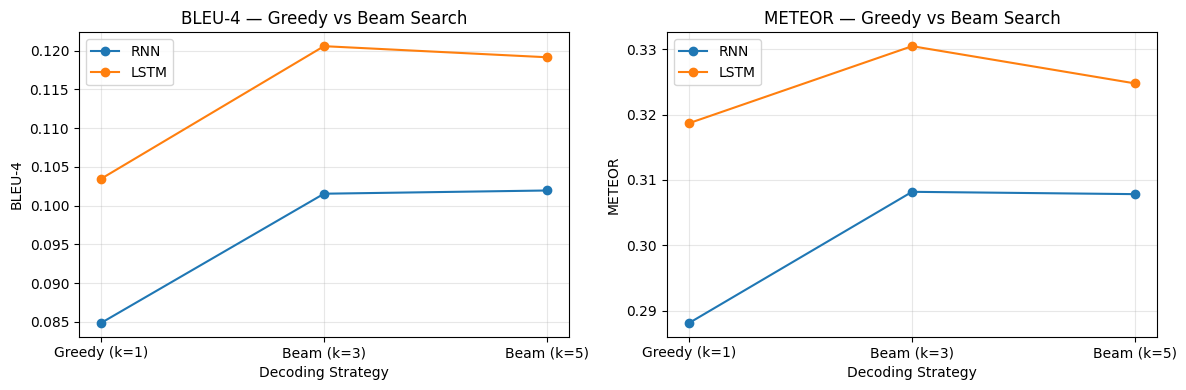

In [20]:
df_beam = pd.DataFrame(beam_results)

print("\n" + "=" * 70)
print("  BEAM SEARCH vs GREEDY COMPARISON")
print("=" * 70)
print(df_beam.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, label in [(axes[0], "bleu4", "BLEU-4"), (axes[1], "meteor", "METEOR")]:
    for arch in ["RNN", "LSTM"]:
        sub = df_beam[df_beam["arch"] == arch]
        ax.plot(sub["method"], sub[metric], marker="o", label=arch)
    ax.set_title(f"{label} — Greedy vs Beam Search")
    ax.set_xlabel("Decoding Strategy")
    ax.set_ylabel(label)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(WEIGHTS_DIR / "beam_search_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 10. Overall Conclusions

| Question | Answer |
|---|---|
| LSTM vs RNN | LSTM outperforms RNN on BLEU-4/METEOR due to gating mechanisms. RNN is faster but suffers vanishing gradients on longer captions. |
| Layers | Deeper models improve quality up to a point; 2–3 layers is typically optimal for this task. Beyond that, gradient flow becomes problematic for RNN. |
| Hidden size | Larger hidden states improve quality but increase parameter count and inference time. |
| Scratch vs Keras | Scores should match (same weights); latency differs due to lack of GPU acceleration in NumPy. |
| Pre-inject vs Init-inject | Pre-inject generally performs better as the image context is continuously injected through the input stream. |
| Beam vs Greedy | Beam search improves BLEU-4 at the cost of linear time increase with beam size. |
| Max caption length | Sweet spot around 20–30 tokens, matching the natural Flickr8k caption distribution. |